In [1]:
import harmonica as hm
import pygmt
import boule as bl

## Nesse notebook vamos mostar como calcular o distúrbio da gravidade para o planeta

In [2]:
#Primeiro importamos os dados que baixamos no site do ICGEM
malha = hm.load_icgem_gdf(
    fname="../dados/gravity_ell_GOCO06s_cf902582486e3c85f5c2d5582f0a853996f51783f517de0a91f8a65894723f61.gdf"
)

In [3]:
#Vamos ver como é a "cara" da nossa malha de dados. Aqui podemos ver as 
# coordenadas, as variáveis e também os atributos da nossa malha
malha

<xarray.Dataset> Size: 12MB
Dimensions:          (latitude: 601, longitude: 1201)
Coordinates:
  * latitude         (latitude) float64 5kB -90.0 -89.7 -89.4 ... 89.4 89.7 90.0
  * longitude        (longitude) float64 10kB -180.0 -179.7 ... 179.7 180.0
Data variables:
    gravity_ell      (latitude, longitude) float64 6MB 9.801e+05 ... 9.801e+05
    height_over_ell  (latitude, longitude) float64 6MB 1e+04 1e+04 ... 1e+04
Attributes: (12/32)
    generating_institute:  gfz-potsdam
    generating_date:       2025/09/25
    product_type:          gravity_field
    body:                  earth
    modelname:             GOCO06s
    max_used_degree:       300
    ...                    ...
    maxvalue:              9.8017493E+05 mgal
    minvalue:              9.7474570E+05 mgal
    signal_wrms:           1.5467801E+03 mgal
    grid_format:           long_lat_value
    attributes:            longitude latitude gravity_ell
    attributes_units:      deg. deg. mgal

In [4]:
# Vamos calcular a gravidade normal usando o boule
gravidade_normal = bl.WGS84.normal_gravity(
    (malha.longitude, malha.latitude, malha.height_over_ell),
)

In [5]:
# Vamos ver a "cara" da nossa malha de gravidade normal no elipsoide WGS84
gravidade_normal

<xarray.DataArray (latitude: 601, longitude: 1201)> Size: 6MB
array([[980142.33509235, 980142.33509235, 980142.33509235, ...,
        980142.33509235, 980142.33509235, 980142.33509235],
       [980142.19216592, 980142.19216592, 980142.19216592, ...,
        980142.19216592, 980142.19216592, 980142.19216592],
       [980141.76340254, 980141.76340254, 980141.76340254, ...,
        980141.76340254, 980141.76340254, 980141.76340254],
       ...,
       [980141.76340254, 980141.76340254, 980141.76340254, ...,
        980141.76340254, 980141.76340254, 980141.76340254],
       [980142.19216592, 980142.19216592, 980142.19216592, ...,
        980142.19216592, 980142.19216592, 980142.19216592],
       [980142.33509235, 980142.33509235, 980142.33509235, ...,
        980142.33509235, 980142.33509235, 980142.33509235]],
      shape=(601, 1201))
Coordinates:
  * latitude   (latitude) float64 5kB -90.0 -89.7 -89.4 -89.1 ... 89.4 89.7 90.0
  * longitude  (longitude) float64 10kB -180.0 -179.7 -179.4 ... 179.7 180.0

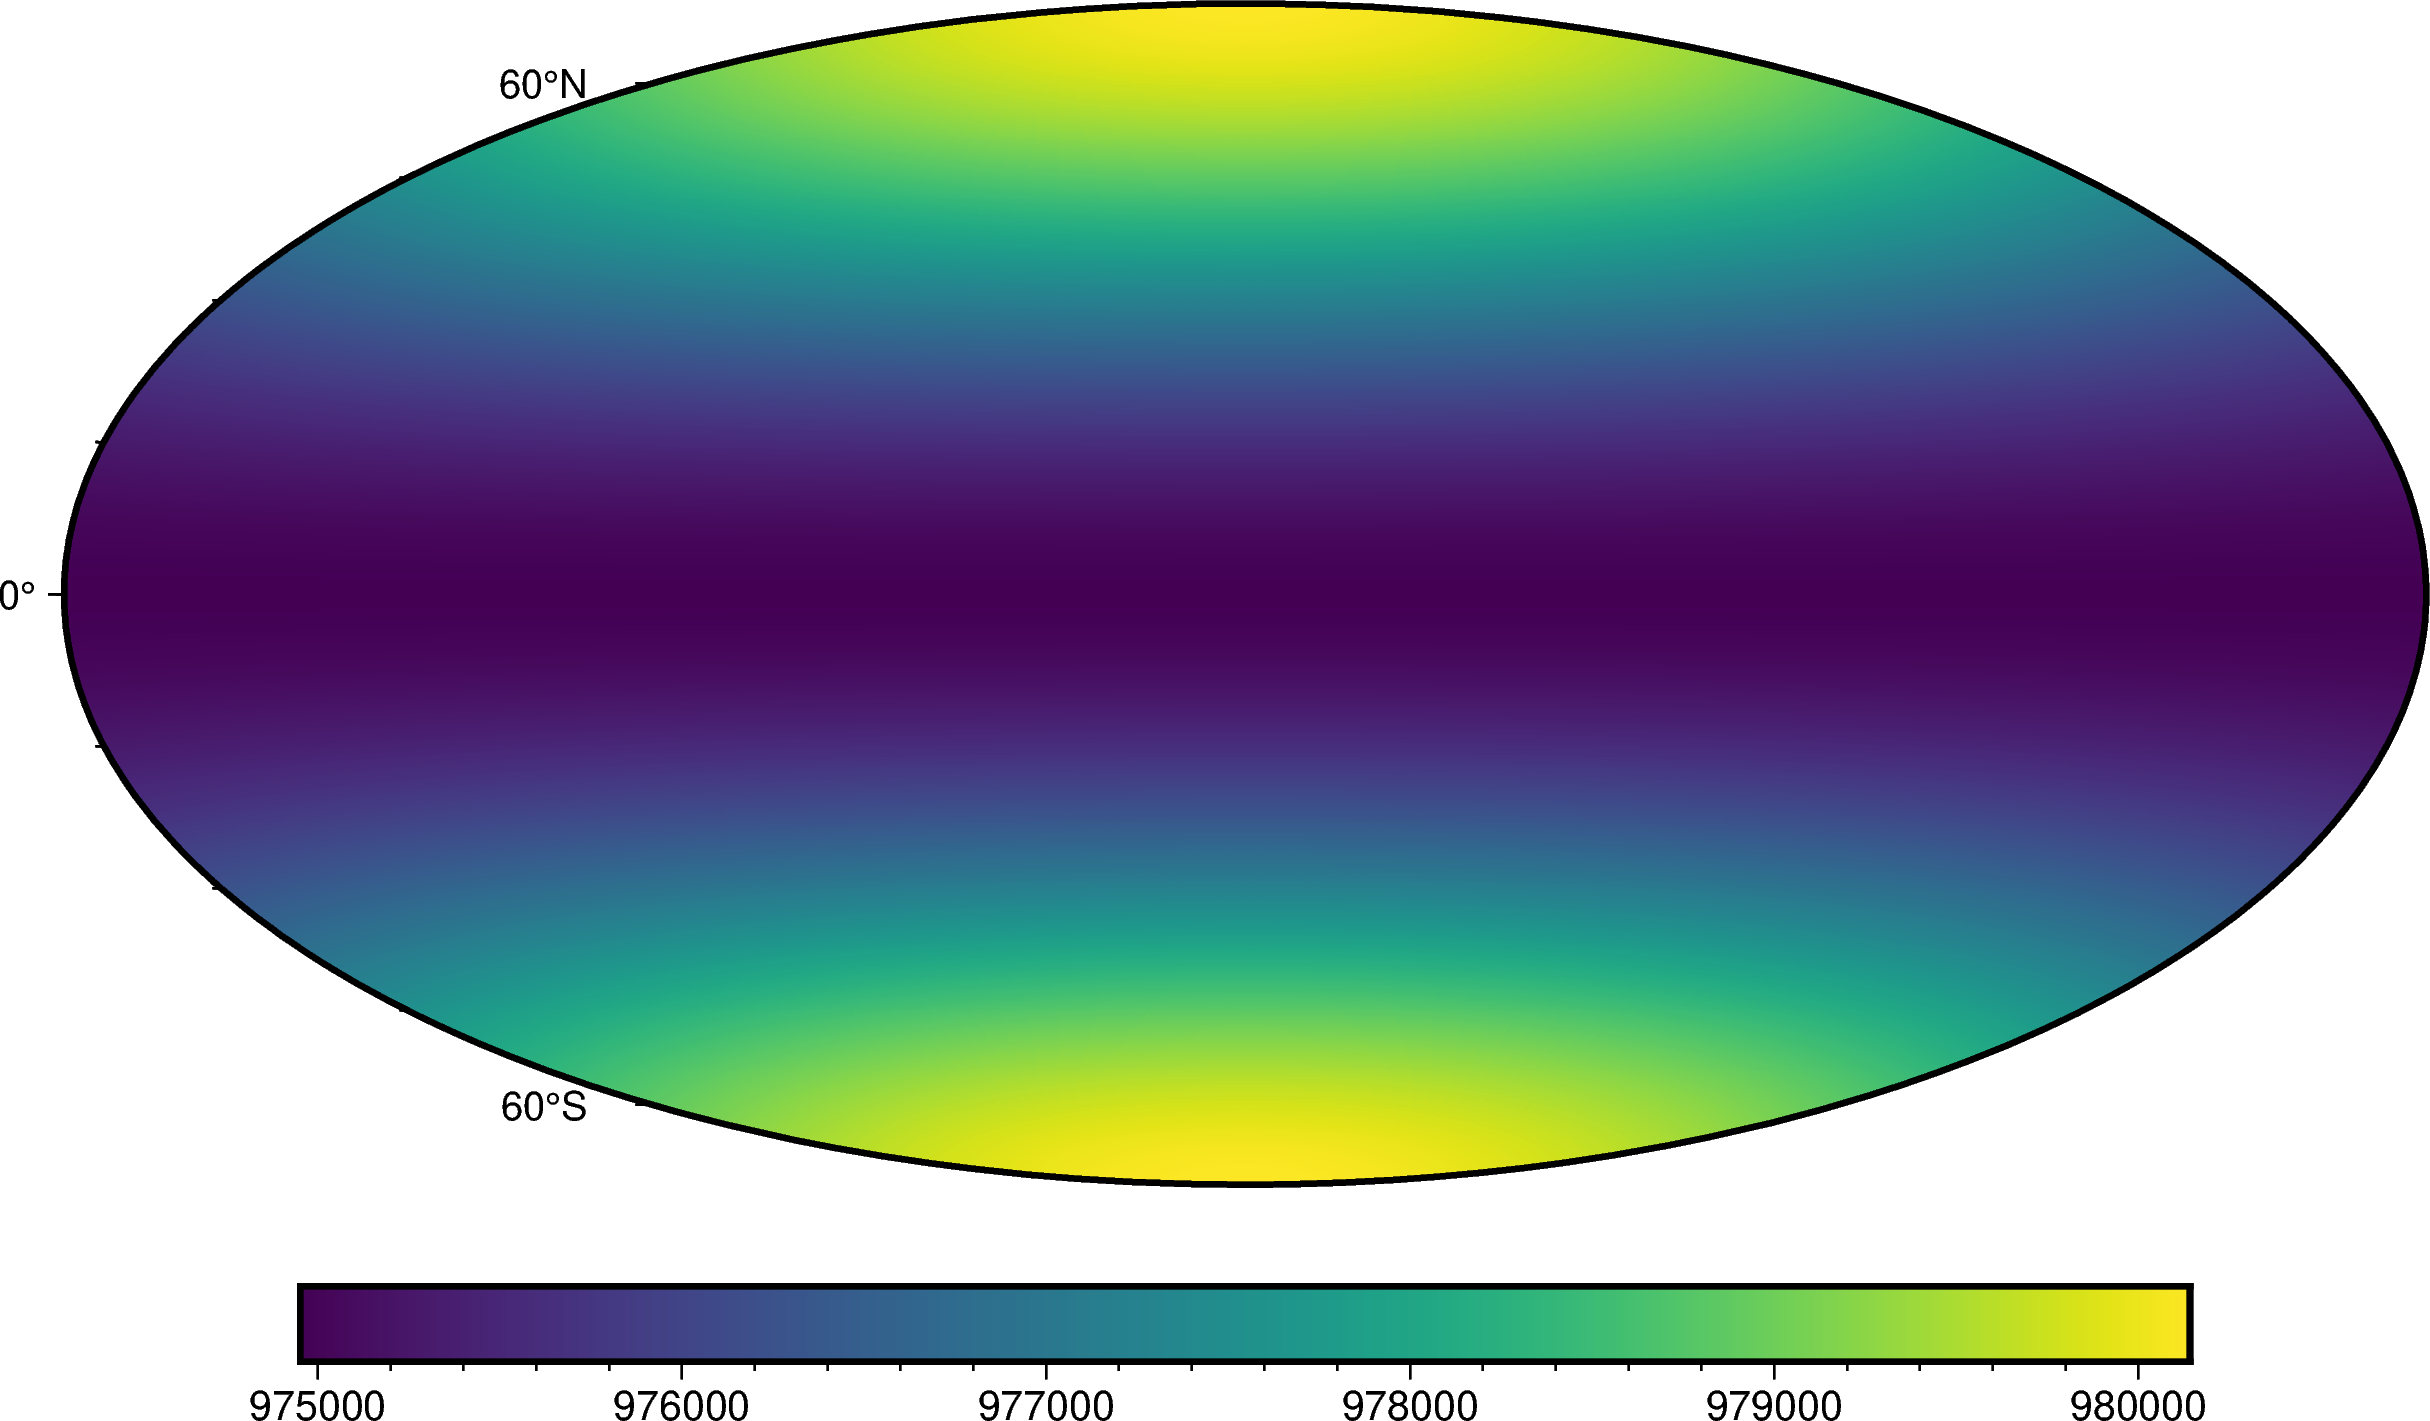

In [6]:
#Vamos plotar nossos dados de gravidade normal
fig = pygmt.Figure()
fig.grdimage(gravidade_normal, projection="H20c", cmap='viridis', frame=True)
fig.colorbar()
fig.show(width=800)

In [7]:
# Vamos calcular o disturbio da gravidade
disturbio = malha.gravity_ell - gravidade_normal

In [8]:
# Vamos ver a "cara" da malha do disturbio
disturbio

<xarray.DataArray (latitude: 601, longitude: 1201)> Size: 6MB
array([[-24.56835603, -24.56835603, -24.56835603, ..., -24.56835603,
        -24.56835603, -24.56835603],
       [-22.50698626, -22.55331451, -22.60005709, ..., -22.41557847,
        -22.46107378, -22.50698626],
       [-22.80485484, -22.86072742, -22.91792372, ..., -22.69707805,
        -22.75030533, -22.80485484],
       ...,
       [ 17.2623089 ,  17.17866506,  17.09448038, ...,  17.42794055,
         17.34540355,  17.2623089 ],
       [  0.73653585,   0.69563316,   0.65445086, ...,   0.81748739,
          0.77715517,   0.73653585],
       [ -9.56228125,  -9.56228125,  -9.56228125, ...,  -9.56228125,
         -9.56228125,  -9.56228125]], shape=(601, 1201))
Coordinates:
  * latitude   (latitude) float64 5kB -90.0 -89.7 -89.4 -89.1 ... 89.4 89.7 90.0
  * longitude  (longitude) float64 10kB -180.0 -179.7 -179.4 ... 179.7 180.0

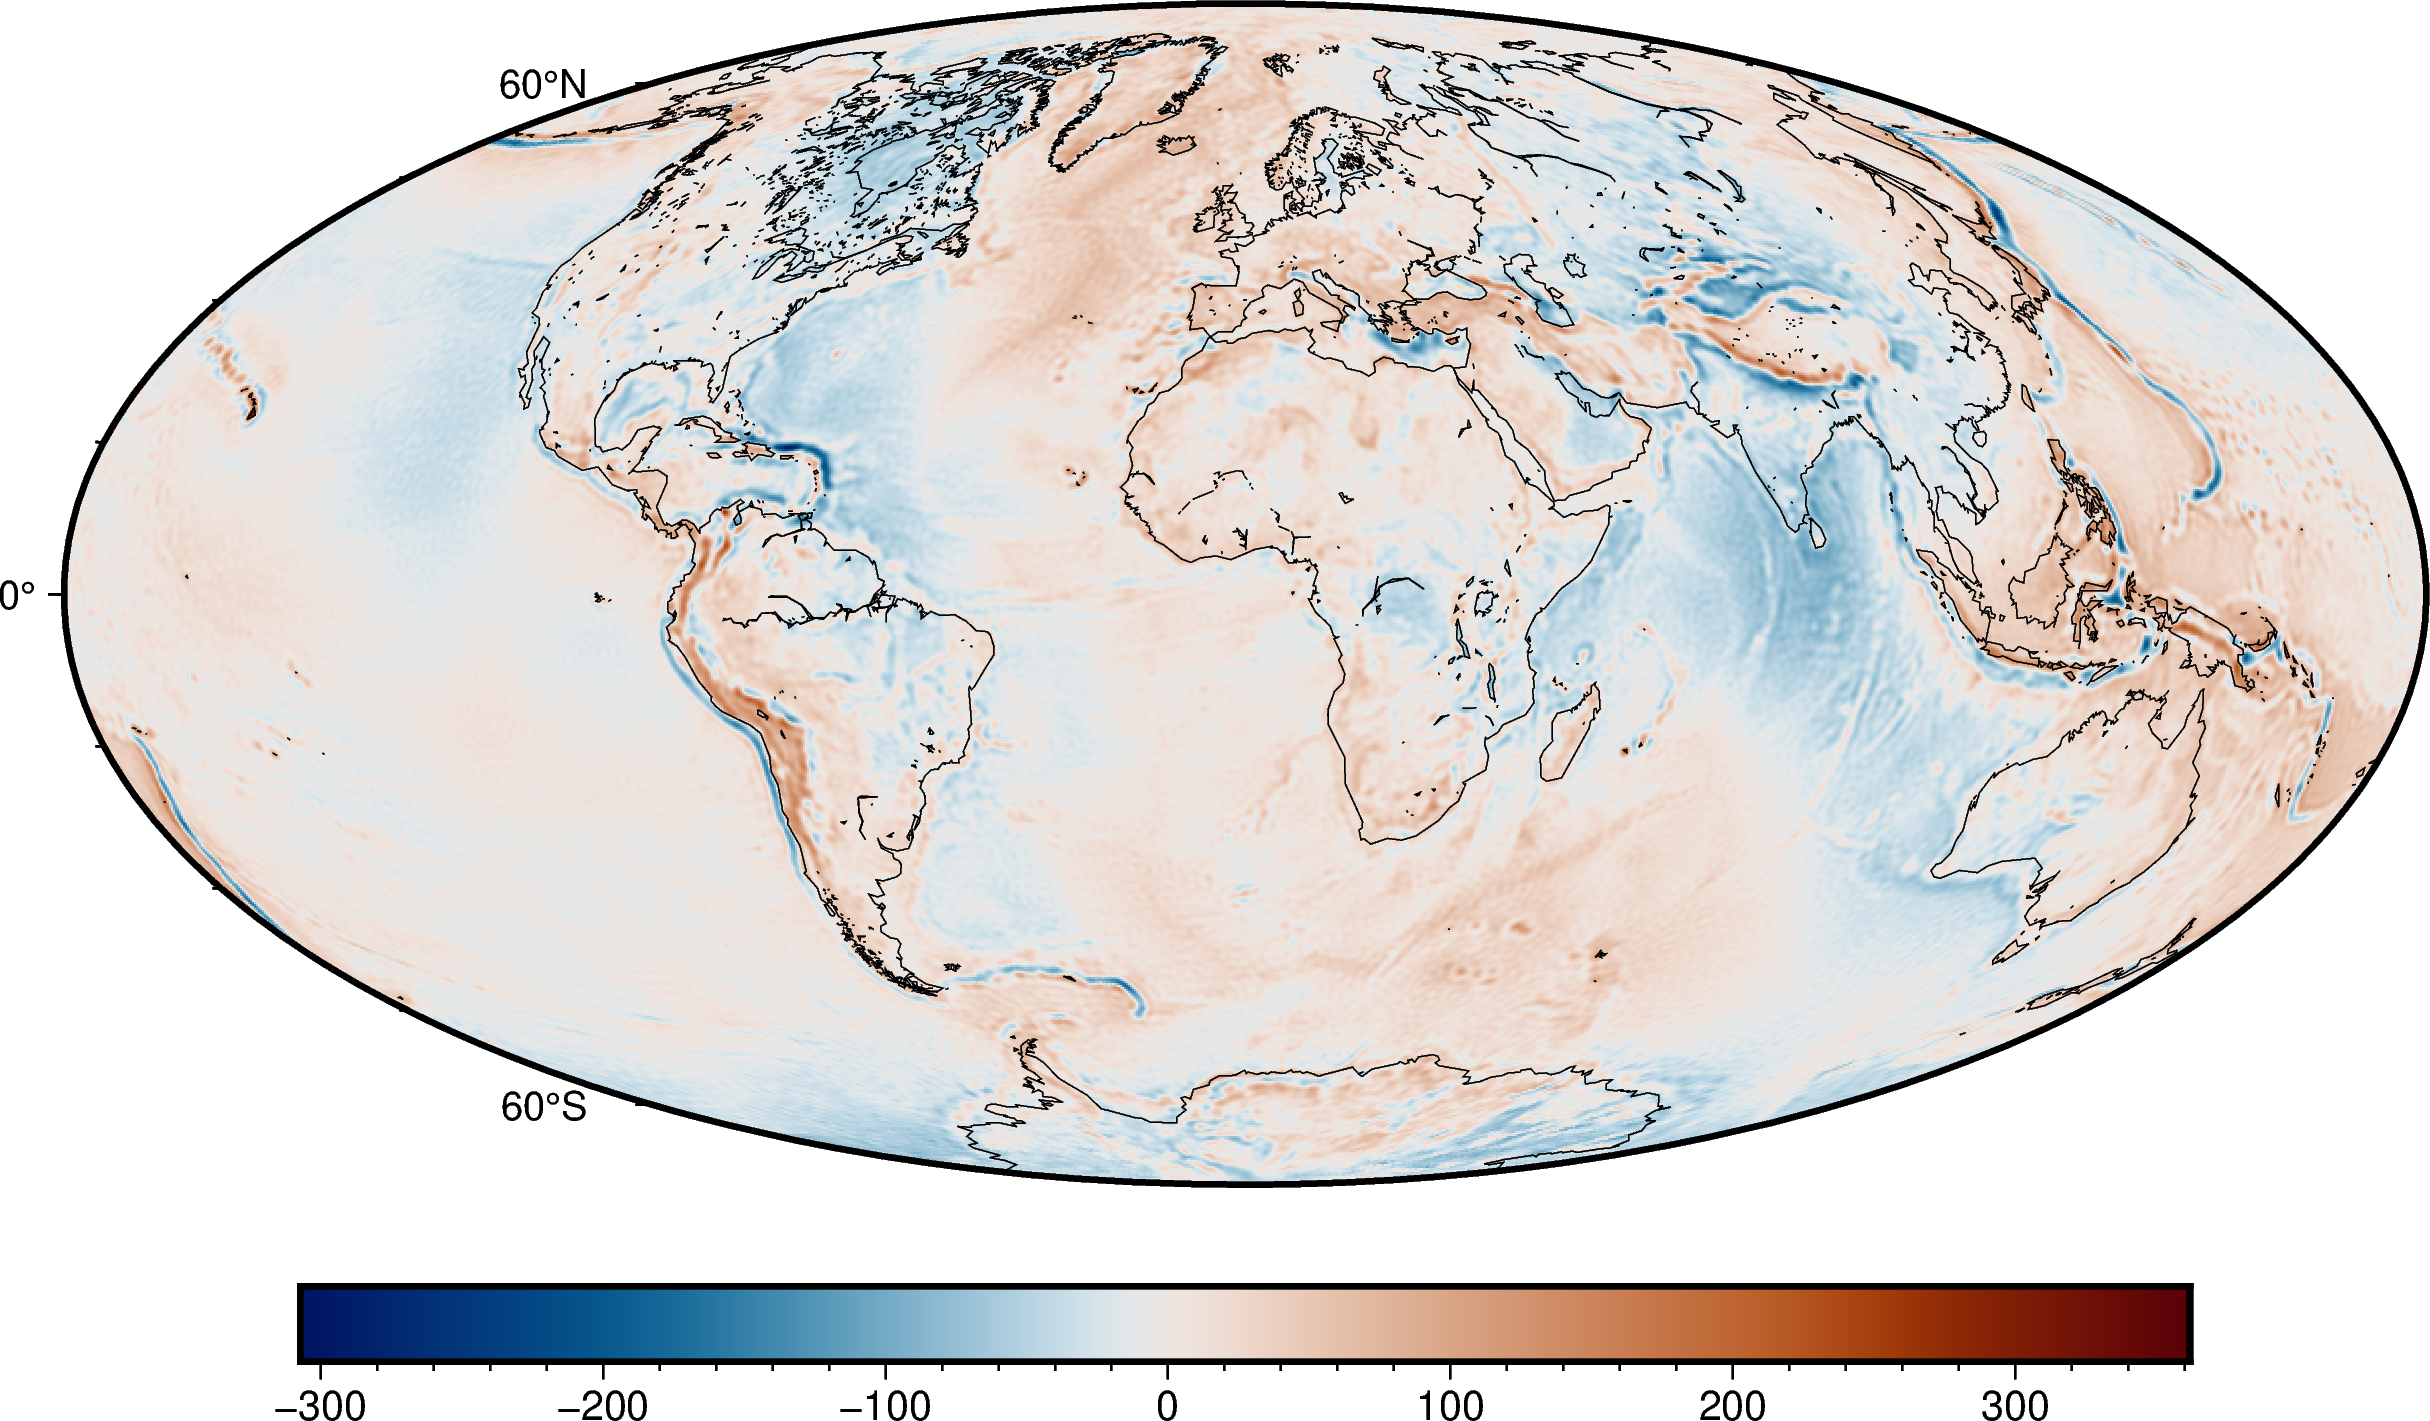

In [9]:
# E agora vamos observar esse disturbio no mapa
fig = pygmt.Figure()
fig.grdimage(disturbio, projection="H20c", cmap='vik+h', frame=True)
fig.coast(shorelines=True)
fig.colorbar()
fig.show(width=800)